# 01 — Accident physics and initial priors

This notebook defines the geometry of the problem.

The guiding principle is to begin with a **conservative prior** centred on the point where the aircraft is expected to first hit the water. If the early missions fail, the search is then progressively displaced along the physical drift direction (developed in notebook 03).

Three building blocks are constructed here:

1. The expected first-contact point with the water, $\mu$.
2. The per-cell physical coordinates, $d_{\mathrm{long}}$ and $d_{\mathrm{trans}}$.
3. The initial priors over the aircraft location.

In [5]:
%load_ext autoreload
%autoreload 2

import warnings; warnings.filterwarnings('ignore')
import sys, os
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from update_version.simulator.grid import load_grid
from update_version.simulator.environment import SearchEnvironment
from update_version.simulator.true_detection import TrueDetector
from update_version.modeling.features import (
    ACCIDENT_POINT, V_PLANE, V_WIND, V_DRIFT, ALPHA_WIND,
    expected_landing, trajectory_axes, cell_distances, evaluate_pi,
)
from update_version.modeling.priors_logistic import PRIORS
from update_version.modeling.detection import DETECTORS
from update_version.strategies.next_mission import (
    hdr_mask, propose_via_hdr_topk, propose_drift_tail_rescue,
    progressive_drift_prior, progressive_scenario_prior,
    apply_drift_tail_escape, apply_progressive_scenario_escape,
    propose_progressive_scenario_search,
)

grid = load_grid('../data/grid_dataset.csv')
BUDGET_CAP = 530


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Expected first-contact point with the water

We use the physical vectors given in the problem statement:

- Accident location: $x_E = (7, 20)$.
- Aircraft velocity: $v_{\mathrm{plane}} = (6, -3.5)$.
- Wind: $v_{\mathrm{wind}} = (-1, -1.5)$.
- Water drift: $v_{\mathrm{drift}} = (0.5, -1.5)$.

During the fall we assume that the wind only partially affects the aircraft, with coupling coefficient
$$
\alpha_{\mathrm{wind}} = 0.5.
$$

The expected point of first contact with the water is
$$
\mu(\tau) = x_E + \tau_{\mathrm{fall}}\,(v_{\mathrm{plane}} + \alpha_{\mathrm{wind}}\,v_{\mathrm{wind}}) + \tau_{\mathrm{drift}}\,v_{\mathrm{drift}}.
$$

Evaluating at the canonical times
$$
\tau_{\mathrm{fall}} = 1, \qquad \tau_{\mathrm{drift}} = 1,
$$
gives the centre of the initial prior.

In [ ]:
mu = expected_landing(1.0, 1.0)
d_norm, n_norm = trajectory_axes()
print('x_E =', ACCIDENT_POINT)
print('mu =', mu)
print('d_norm =', d_norm)
print('n_norm =', n_norm)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(*ACCIDENT_POINT, s=90, color='white', edgecolor='black', label='x_E')
ax.scatter(*mu, s=100, color='red', marker='x', label='mu: expected first contact')
ax.arrow(mu[0], mu[1], d_norm[0]*5, d_norm[1]*5, width=0.08, color='tab:blue')
ax.arrow(mu[0], mu[1], n_norm[0]*3, n_norm[1]*3, width=0.05, color='tab:orange')
ax.text(mu[0]+d_norm[0]*5, mu[1]+d_norm[1]*5, 'd_long', color='tab:blue')
ax.text(mu[0]+n_norm[0]*3, mu[1]+n_norm[1]*3, 'd_trans', color='tab:orange')
ax.set_xlim(0, 30); ax.set_ylim(0, 25); ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend()
ax.set_title('Accident geometry: x_E, expected impact mu, trajectory axes')
plt.show()

## Per-cell physical coordinates

For each cell $j$ with centre $(x_j, y_j)$ we compute two coordinates relative to $\mu$.

The first measures progress along the dominant trajectory direction:
$$
d_{\mathrm{long},j} = \bigl((x_j, y_j) - \mu\bigr) \cdot \hat d_{\mathrm{norm}}.
$$

The second measures lateral displacement from that trajectory:
$$
d_{\mathrm{trans},j} = \bigl((x_j, y_j) - \mu\bigr) \cdot \hat n_{\mathrm{norm}}.
$$

Interpretation:

- $d_{\mathrm{long}} > 0$: the cell lies ahead along the physical trajectory.
- $d_{\mathrm{long}} < 0$: the cell lies behind the expected point.
- $d_{\mathrm{trans}} > 0$: the cell lies on one side of the trajectory.
- $d_{\mathrm{trans}} < 0$: the cell lies on the other side.

This decomposition matters because the witness statements suggest three reasonable hypotheses: a centred fall, a fall biased to the right, or a fall biased to the left of the trajectory.

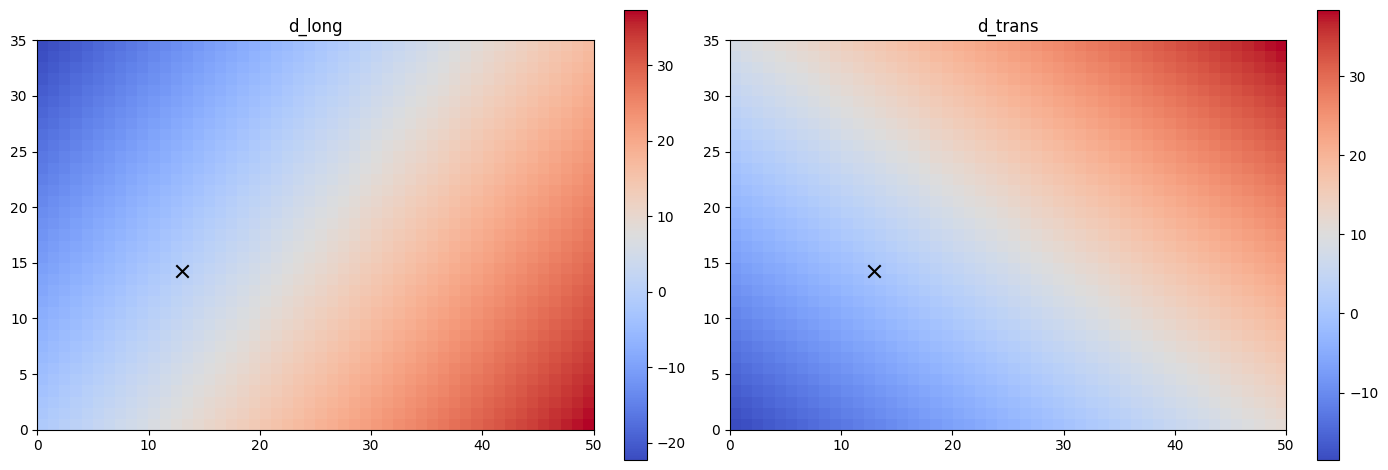

In [7]:
d_long, d_trans = cell_distances(grid.x, grid.y, 1.0, 1.0)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, values, title in [(axes[0], d_long, 'd_long'), (axes[1], d_trans, 'd_trans')]:
    im = ax.imshow(grid.reshape_2d(values), origin='lower', extent=[0, grid.Nx, 0, grid.Ny], cmap='coolwarm')
    ax.scatter(*mu, color='black', marker='x', s=80)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## Prior over cells

The prior over the cell containing the aircraft is given by a logistic softmax:
$$
\pi_j(\beta, \tau) = \operatorname{softmax}_j(\eta_j).
$$

The linear predictor is
$$
\eta_j = \beta_0 + \beta_1 d_{\mathrm{long},j} + \beta_2 d_{\mathrm{trans},j}
          - \beta_3 d_{\mathrm{long},j}^2 - \beta_4 d_{\mathrm{trans},j}^2.
$$

The quadratic terms generate the initial concentration around $\mu$. The operational priors **P11 to P14** represent different levels of uncertainty around the expected first-contact point — their values were *derived* from a sweep over earlier priors (see [00_model_selection_history.ipynb](00_model_selection_history.ipynb) §5).

Important: these priors are **not** centred on a final search zone. Any final zone emerges only if data from failed missions justify a physically-grounded displacement (see [03_progressive_drift_strategy.ipynb](03_progressive_drift_strategy.ipynb)).

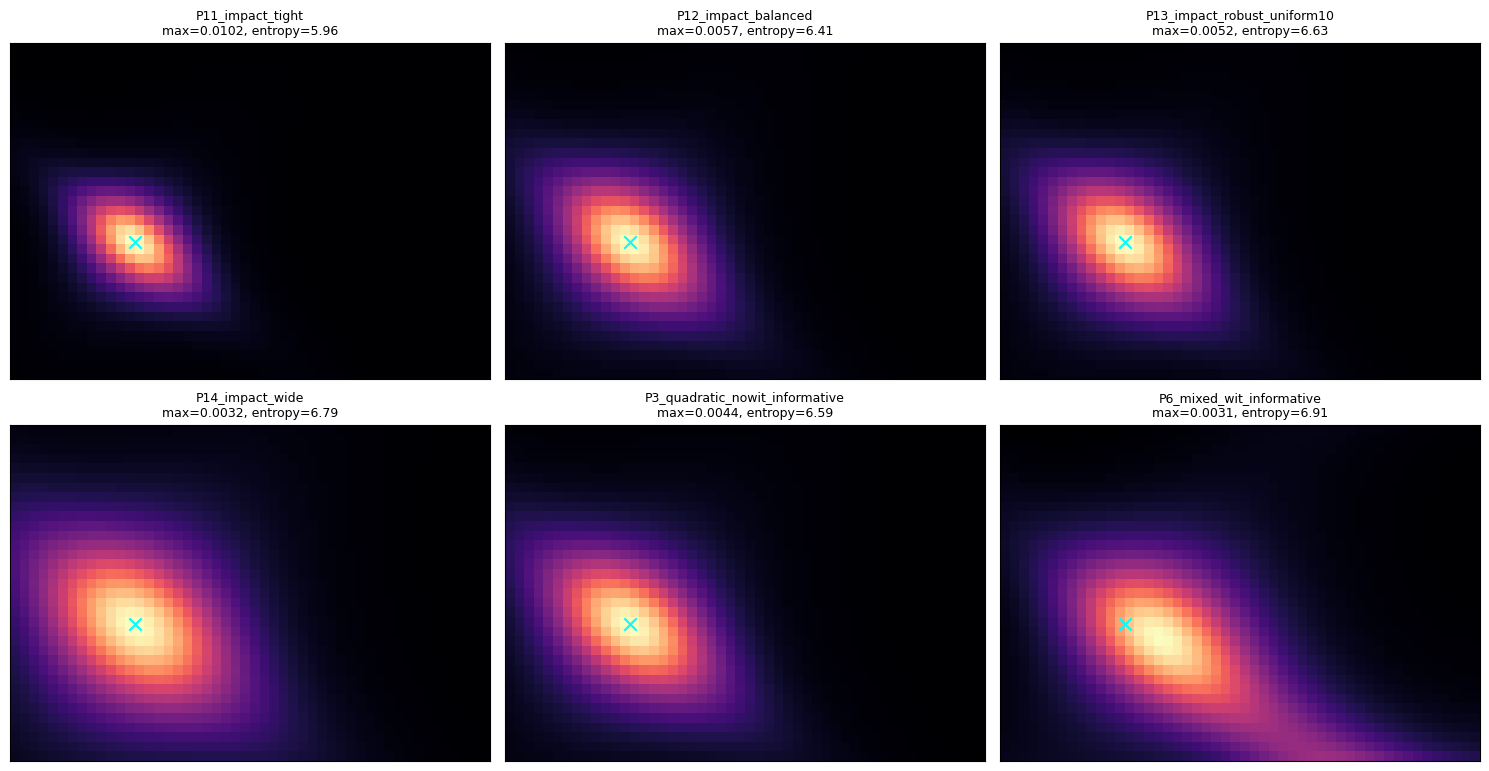

In [8]:
prior_names = ['P11_impact_tight', 'P12_impact_balanced', 'P13_impact_robust_uniform10', 'P14_impact_wide', 'P3_quadratic_nowit_informative', 'P6_mixed_wit_informative']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, name in zip(axes.flat, prior_names):
    pi = PRIORS[name].prior_predictive_pi(grid.x, grid.y, n_samples=700, seed=0)
    ax.imshow(grid.reshape_2d(pi), origin='lower', extent=[0, grid.Nx, 0, grid.Ny], cmap='magma')
    ax.scatter(*mu, color='cyan', marker='x', s=80)
    ax.set_title(f'{name}\nmax={pi.max():.4f}, entropy={-(pi*np.log(np.clip(pi,1e-300,None))).sum():.2f}', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()